## Block 0 — Setup

In [1]:
import os
import sys
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR     = PROJECT_ROOT / 'data' / 'ved'
MODELS_DIR   = PROJECT_ROOT / 'models'
OUTPUTS_DIR  = PROJECT_ROOT / 'outputs'

(MODELS_DIR / 'pkl').mkdir(parents=True, exist_ok=True)
(MODELS_DIR / 'onnx').mkdir(parents=True, exist_ok=True)
(OUTPUTS_DIR / 'data').mkdir(parents=True, exist_ok=True)
(OUTPUTS_DIR / 'plots').mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
sns.set_palette('Set2')

Project root: d:\v2
Data dir:     d:\v2\data\ved


## Block 1 — Load VED static data

In [2]:
static_files = sorted((DATA_DIR).glob('VED_Static_Data_*.xlsx'))
print(f"Found {len(static_files)} static data files:")
for f in static_files:
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

static_dfs = []
for f in static_files:
    sdf = pd.read_excel(f)
    static_dfs.append(sdf)
    print(f"\n{f.name}: shape={sdf.shape}")
    print(f"  Columns: {list(sdf.columns)}")

static = pd.concat(static_dfs, ignore_index=True)
print(f"\nCombined static: {static.shape}")
print(f"Unique vehicles: {static['VehId'].nunique() if 'VehId' in static.columns else 'N/A'}")
print(f"\nFirst 3 rows:")
print(static.head(3).to_string())

Found 2 static data files:
  VED_Static_Data_ICE&HEV.xlsx  (20.7 KB)
  VED_Static_Data_PHEV&EV.xlsx  (9.5 KB)

VED_Static_Data_ICE&HEV.xlsx: shape=(357, 7)
  Columns: ['VehId', 'Vehicle Type', 'Vehicle Class', 'Engine Configuration & Displacement', 'Transmission', 'Drive Wheels', 'Generalized_Weight']

VED_Static_Data_PHEV&EV.xlsx: shape=(27, 7)
  Columns: ['VehId', 'EngineType', 'Vehicle Class', 'Engine Configuration & Displacement', 'Transmission', 'Drive Wheels', 'Generalized_Weight']

Combined static: (384, 8)
Unique vehicles: 384

First 3 rows:
   VehId Vehicle Type Vehicle Class Engine Configuration & Displacement Transmission Drive Wheels Generalized_Weight EngineType
0      2          ICE           Car                       4-FI 2.0L T/C      NO DATA      NO DATA               3500        NaN
1      5          HEV           Car                 4-GAS/ELECTRIC 2.0L      NO DATA      NO DATA               3500        NaN
2      7          ICE           SUV                         

## Block 2  —  Load and aggregate VED dynamic data

In [3]:
dynamic_dir = DATA_DIR / 'VED_Dynamic_Data'
if not dynamic_dir.exists():
    raise FileNotFoundError(f"VED_Dynamic_Data folder not found at {dynamic_dir}")

dyn_files = sorted(dynamic_dir.glob('*.csv'))
print(f"Found {len(dyn_files)} dynamic CSV files")
print(f"Total size: {sum(f.stat().st_size for f in dyn_files) / 1024 / 1024:.1f} MB")

USE_COLS = [
    'VehId', 'Trip', 'Timestamp(ms)',
    'Vehicle Speed[km/h]', 'MAF[g/sec]', 'Engine RPM[RPM]',
    'Absolute Load[%]', 'OAT[DegC]', 'Fuel Rate[L/hr]',
]

t0 = time.time()
trip_chunks = []
for i, fpath in enumerate(dyn_files, 1):
    df = pd.read_csv(fpath, usecols=USE_COLS)
    print(f"  [{i:2}/{len(dyn_files)}] {fpath.name:30}  rows={len(df):>9,}  vehicles={df['VehId'].nunique():>4}", end='\r')
    trip_chunks.append(df)

print(f"\n\nLoaded all {len(dyn_files)} files in {time.time()-t0:.1f} sec")

dyn_all = pd.concat(trip_chunks, ignore_index=True)
del trip_chunks

print(f"\nTotal raw rows: {len(dyn_all):,}")
print(f"Unique (VehId, Trip) pairs: {dyn_all.groupby(['VehId', 'Trip']).ngroups:,}")
print(f"Unique vehicles:            {dyn_all['VehId'].nunique():,}")

t0 = time.time()
agg_dict = {
    'Timestamp(ms)':         ['min', 'max', 'count'],
    'Vehicle Speed[km/h]':   ['mean', 'max', 'std'],
    'MAF[g/sec]':            ['mean', 'max'],
    'Engine RPM[RPM]':       ['mean', 'max', 'std'],
    'Absolute Load[%]':      ['mean', 'max'],
    'OAT[DegC]':             ['mean'],
    'Fuel Rate[L/hr]':       ['mean', 'sum'],
}

trips = dyn_all.groupby(['VehId', 'Trip']).agg(agg_dict)
trips.columns = ['_'.join(c).strip() for c in trips.columns]
trips = trips.reset_index()

trips['duration_sec'] = (trips['Timestamp(ms)_max'] - trips['Timestamp(ms)_min']) / 1000.0
trips['n_readings']   = trips['Timestamp(ms)_count']

idle_mask = dyn_all['Vehicle Speed[km/h]'] < 1
idle_counts = dyn_all[idle_mask].groupby(['VehId', 'Trip']).size().rename('idle_readings')
trips = trips.merge(idle_counts, on=['VehId', 'Trip'], how='left')
trips['idle_readings'] = trips['idle_readings'].fillna(0)
trips['idle_fraction'] = trips['idle_readings'] / trips['n_readings'].clip(lower=1)

trips = trips.drop(columns=['Timestamp(ms)_min', 'Timestamp(ms)_max', 'Timestamp(ms)_count'])

print(f"\nTrip aggregation in {time.time()-t0:.1f} sec")

before = len(trips)
trips = trips[trips['duration_sec'] >= 60]
trips = trips[trips['n_readings'] >= 30]
trips = trips[trips['Vehicle Speed[km/h]_mean'].notna()]
print(f"Filtered: {before:,} → {len(trips):,} trips")

del dyn_all
print(f"\nFinal trips DataFrame: {trips.shape}")

Found 54 dynamic CSV files
Total size: 3055.1 MB
  [54/54] VED_181107_week.csv             rows=  118,327  vehicles=  95

Loaded all 54 files in 40.2 sec

Total raw rows: 22,436,808
Unique (VehId, Trip) pairs: 32,552
Unique vehicles:            384

Trip aggregation in 5.6 sec
Filtered: 32,552 → 32,452 trips

Final trips DataFrame: (32452, 19)


## Block 3  — Isolation Forest fleet-wide ranking

Features used (17):
  - Vehicle Speed[km/h]_mean
  - Vehicle Speed[km/h]_max
  - Vehicle Speed[km/h]_std
  - MAF[g/sec]_mean
  - MAF[g/sec]_max
  - Engine RPM[RPM]_mean
  - Engine RPM[RPM]_max
  - Engine RPM[RPM]_std
  - Absolute Load[%]_mean
  - Absolute Load[%]_max
  - OAT[DegC]_mean
  - Fuel Rate[L/hr]_mean
  - Fuel Rate[L/hr]_sum
  - duration_sec
  - n_readings
  - idle_readings
  - idle_fraction

NaN count: 75,993  (13.77% of values)

Trained in 0.7 sec on 32,452 trips × 17 features

Anomaly score distribution:
  Min:    0.3519
  Median: 0.4125
  Mean:   0.4268
  Max:    0.7002


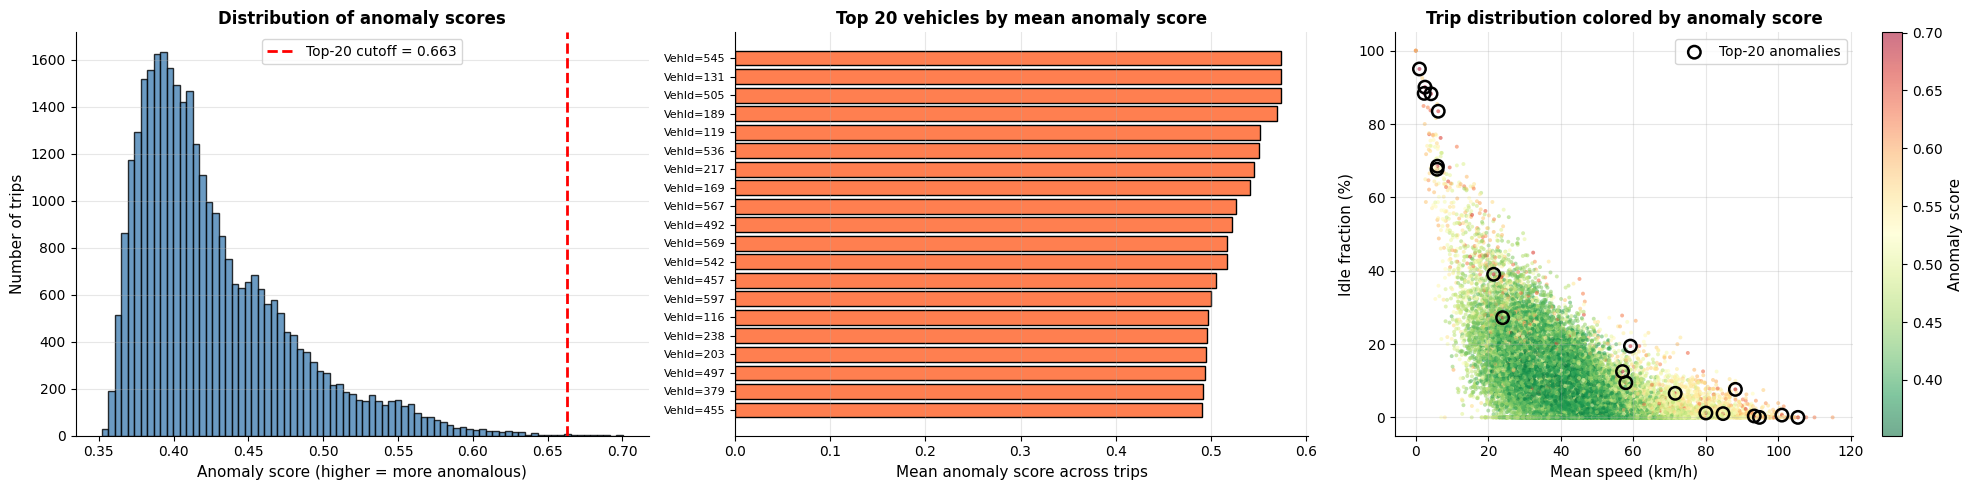

In [4]:
from sklearn.ensemble import IsolationForest

FEATURE_COLS = [
    'Vehicle Speed[km/h]_mean', 'Vehicle Speed[km/h]_max', 'Vehicle Speed[km/h]_std',
    'MAF[g/sec]_mean', 'MAF[g/sec]_max',
    'Engine RPM[RPM]_mean', 'Engine RPM[RPM]_max', 'Engine RPM[RPM]_std',
    'Absolute Load[%]_mean', 'Absolute Load[%]_max',
    'OAT[DegC]_mean',
    'Fuel Rate[L/hr]_mean', 'Fuel Rate[L/hr]_sum',
    'duration_sec', 'n_readings', 'idle_readings', 'idle_fraction',
]

print(f"Features used ({len(FEATURE_COLS)}):")
for c in FEATURE_COLS:
    print(f"  - {c}")

if 'anomaly_score' in trips.columns:
    trips = trips.drop(columns=['anomaly_score'])

X = trips[FEATURE_COLS].values.astype(np.float32)
n_nan = np.isnan(X).sum()
print(f"\nNaN count: {n_nan:,}  ({n_nan / X.size * 100:.2f}% of values)")
X = np.nan_to_num(X, nan=0.0)

if_params = {
    'n_estimators': 200,
    'max_samples': 'auto',
    'contamination': 'auto',
    'random_state': SEED,
    'n_jobs': -1,
}

t0 = time.time()
iforest = IsolationForest(**if_params)
iforest.fit(X)
train_time = time.time() - t0

trips['anomaly_score'] = -iforest.score_samples(X)

print(f"\nTrained in {train_time:.1f} sec on {len(X):,} trips × {X.shape[1]} features")
print(f"\nAnomaly score distribution:")
print(f"  Min:    {trips['anomaly_score'].min():.4f}")
print(f"  Median: {trips['anomaly_score'].median():.4f}")
print(f"  Mean:   {trips['anomaly_score'].mean():.4f}")
print(f"  Max:    {trips['anomaly_score'].max():.4f}")

trips_ranked = trips.sort_values('anomaly_score', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax = axes[0]
ax.hist(trips['anomaly_score'], bins=80, color='steelblue', edgecolor='black', alpha=0.8)
top20_cutoff = trips_ranked['anomaly_score'].iloc[20]
ax.axvline(top20_cutoff, color='red', linestyle='--', linewidth=2,
           label=f"Top-20 cutoff = {top20_cutoff:.3f}")
ax.set_xlabel('Anomaly score (higher = more anomalous)')
ax.set_ylabel('Number of trips')
ax.set_title('Distribution of anomaly scores', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
vehicle_anomaly = trips.groupby('VehId')['anomaly_score'].mean().sort_values(ascending=False)
top_vehicles = vehicle_anomaly.head(20)
ax.barh(range(len(top_vehicles)), top_vehicles.values[::-1], color='coral', edgecolor='black')
ax.set_yticks(range(len(top_vehicles)))
ax.set_yticklabels([f"VehId={v}" for v in top_vehicles.index[::-1]], fontsize=8)
ax.set_xlabel('Mean anomaly score across trips')
ax.set_title('Top 20 vehicles by mean anomaly score', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

ax = axes[2]
scatter = ax.scatter(
    trips['Vehicle Speed[km/h]_mean'],
    trips['idle_fraction'] * 100,
    c=trips['anomaly_score'],
    s=8,
    cmap='RdYlGn_r',
    alpha=0.55,
    edgecolors='none',
)

top20_in_scatter = trips_ranked.head(20)
ax.scatter(
    top20_in_scatter['Vehicle Speed[km/h]_mean'],
    top20_in_scatter['idle_fraction'] * 100,
    s=80,
    facecolors='none',
    edgecolors='black',
    linewidths=1.8,
    zorder=5,
    label='Top-20 anomalies',
)

plt.colorbar(scatter, ax=ax, label='Anomaly score')
ax.set_xlabel('Mean speed (km/h)')
ax.set_ylabel('Idle fraction (%)')
ax.set_title('Trip distribution colored by anomaly score', fontsize=12, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'ved_01_anomaly_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

## Block 4  — Top-20 anomalies — qualitative analysis

Top 20 anomalous trips:
Rank  VehId   Trip     Score    Speed mean   RPM max    Idle %   Duration  
---------------------------------------------------------------------------
  1   189     2030     0.700    2.3          1975       88.4     6560      
  2   189     2425     0.699    1.0          2089       95.0     7326      
  3   169     1641     0.696    2.5          2637       90.1     10121     
  4   454     1829     0.687    4.2          2879       88.2     4605      
  5   492     1741     0.685    88.2         4070       7.6      1941      
  6   542     1895     0.684    57.0         3378       12.5     1990      
  7   536     485      0.684    80.1         3612       1.2      4751      
  8   569     1573     0.682    21.5         2424       39.0     8009      
  9   569     750      0.681    84.8         3000       1.0      4386      
  10  569     358      0.680    23.9         2407       27.2     4569      
  11  189     1910     0.679    6.0          2557       68.5    

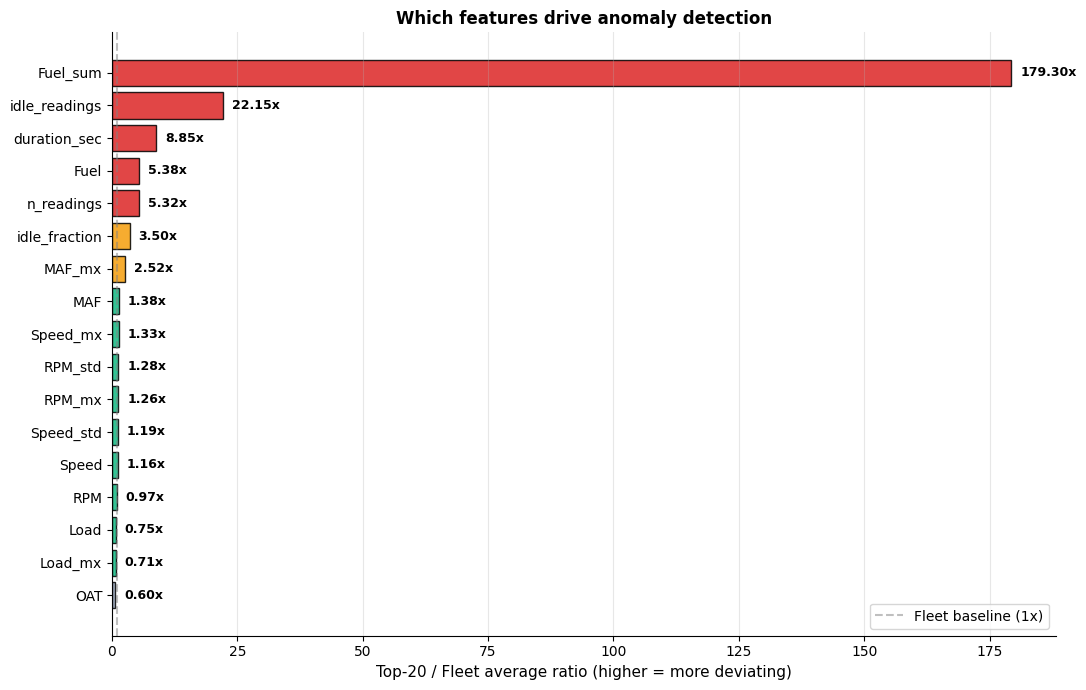

In [5]:
top20 = trips_ranked.head(20).copy()

print(f"Top 20 anomalous trips:")
print(f"{'Rank':<5} {'VehId':<7} {'Trip':<8} {'Score':<8} {'Speed mean':<12} {'RPM max':<10} {'Idle %':<8} {'Duration':<10}")
print("-" * 75)
for i, row in top20.iterrows():
    print(f"  {i+1:<3} {int(row['VehId']):<7} {int(row['Trip']):<8} {row['anomaly_score']:<8.3f} "
          f"{row['Vehicle Speed[km/h]_mean']:<12.1f} {row['Engine RPM[RPM]_max']:<10.0f} "
          f"{row['idle_fraction']*100:<8.1f} {row['duration_sec']:<10.0f}")

fleet_mean = trips[FEATURE_COLS].mean()
top20_mean = top20[FEATURE_COLS].mean()

print(f"\nTop-20 anomalies vs fleet average:")
print(f"{'Feature':<35} {'Fleet avg':>14} {'Top-20 avg':>14} {'Ratio':>10}")
print("-" * 80)
ratios = {}
for col in FEATURE_COLS:
    fleet_val = fleet_mean[col]
    anom_val = top20_mean[col]
    ratio = anom_val / fleet_val if abs(fleet_val) > 1e-6 else float('inf')
    print(f"  {col:<33} {fleet_val:>14.2f} {anom_val:>14.2f} {ratio:>10.2f}x")
    ratios[col] = ratio

print(f"\nQualitative observations on top-3 trips:")
for rank in range(3):
    trip = trips_ranked.iloc[rank]
    obs = []
    if trip['Vehicle Speed[km/h]_mean'] > fleet_mean['Vehicle Speed[km/h]_mean'] * 1.5:
        obs.append(f"high mean speed ({trip['Vehicle Speed[km/h]_mean']:.1f} km/h)")
    if trip['Vehicle Speed[km/h]_mean'] < fleet_mean['Vehicle Speed[km/h]_mean'] * 0.3:
        obs.append(f"very low mean speed ({trip['Vehicle Speed[km/h]_mean']:.1f} km/h)")
    if trip['Engine RPM[RPM]_max'] > 4000:
        obs.append(f"high RPM peak ({trip['Engine RPM[RPM]_max']:.0f} rpm)")
    if trip['idle_fraction'] > 0.5:
        obs.append(f"high idle fraction ({trip['idle_fraction']*100:.0f}%)")
    if trip['idle_fraction'] < 0.02:
        obs.append(f"almost no idle time ({trip['idle_fraction']*100:.1f}%)")
    if trip['duration_sec'] > 5000:
        obs.append(f"very long trip ({trip['duration_sec']/60:.0f} min)")
    if trip['duration_sec'] < 120:
        obs.append(f"very short trip ({trip['duration_sec']:.0f} sec)")
    if trip['Engine RPM[RPM]_std'] > 800:
        obs.append(f"variable RPM (std={trip['Engine RPM[RPM]_std']:.0f})")
    
    print(f"\nRank {rank+1}: VehId={int(trip['VehId'])}, Trip={int(trip['Trip'])}, score={trip['anomaly_score']:.3f}")
    for o in obs:
        print(f"  - {o}")

fig, ax = plt.subplots(figsize=(11, 7))

sorted_features = sorted(ratios.items(), key=lambda x: x[1], reverse=True)
feat_names_short = [f.replace('_mean', '').replace('_max', '_mx').replace('_std', '_std')
                    .replace('Vehicle Speed[km/h]', 'Speed')
                    .replace('Engine RPM[RPM]', 'RPM')
                    .replace('Absolute Load[%]', 'Load')
                    .replace('Fuel Rate[L/hr]', 'Fuel')
                    .replace('MAF[g/sec]', 'MAF')
                    .replace('OAT[DegC]', 'OAT')
                    for f, _ in sorted_features]
ratio_values = [r for _, r in sorted_features]

colors = ['#dc2626' if r > 5 else ('#f59e0b' if r > 1.5 else ('#10b981' if r > 0.7 else '#94a3b8'))
          for r in ratio_values]

bars = ax.barh(range(len(feat_names_short)), ratio_values[::-1], color=colors[::-1],
               edgecolor='black', alpha=0.85)
for bar, val in zip(bars, ratio_values[::-1]):
    label_x = bar.get_width() + max(ratio_values) * 0.01
    ax.text(label_x, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}x', va='center', fontsize=9, fontweight='bold')

ax.axvline(1.0, color='gray', linestyle='--', alpha=0.5, label='Fleet baseline (1x)')
ax.set_yticks(range(len(feat_names_short)))
ax.set_yticklabels(feat_names_short[::-1], fontsize=10)
ax.set_xlabel('Top-20 / Fleet average ratio (higher = more deviating)')
ax.set_title('Which features drive anomaly detection',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'ved_02_feature_ratios.png', bbox_inches='tight', dpi=120)
plt.show()

In [7]:
import plotly.graph_objects as go

# ═══ Plotly scatter: full fleet (sampled) + top-20 overlay ═══
# Background: sample 3000 trips for performant browser rendering.
# Foreground: top-20 trips with bigger markers and full hover detail.

BG_SAMPLE_SIZE = 3000

# Background sample (deterministic via seed)
rng = np.random.RandomState(SEED)
n_total = len(trips)
sample_idx = rng.choice(n_total, min(BG_SAMPLE_SIZE, n_total), replace=False)
bg = trips.iloc[sample_idx].copy()

# Top-20 (use trips_ranked which is already sorted)
top20_df = trips_ranked.head(20).copy()

# Build hover text for each top-20 trip
def _format_duration(sec):
    m = int(sec // 60); s = int(sec % 60)
    return f'{m}m {s:02d}s'

top20_hover = []
for rank_pos, (_, t) in enumerate(top20_df.iterrows(), start=1):
    speed = t['Vehicle Speed[km/h]_mean']
    idle_pct = t['idle_fraction'] * 100
    rpm = t.get('Engine RPM[RPM]_max', 0)
    dur = t.get('duration_sec', 0)
    h = (f"<b>Rank #{rank_pos} — V{int(t['VehId'])} Trip {int(t['Trip'])}</b><br>"
         f"Anomaly score: <b>{t['anomaly_score']:.3f}</b><br><br>"
         f"Mean speed:  {speed:.1f} km/h<br>"
         f"Max RPM:     {rpm:.0f} rpm<br>"
         f"Idle:        {idle_pct:.1f}%<br>"
         f"Duration:    {_format_duration(dur)}")
    top20_hover.append(h)

fig = go.Figure()

# ── Background trace: all sampled trips ──────────────────
fig.add_trace(go.Scatter(
    x=bg['Vehicle Speed[km/h]_mean'],
    y=bg['idle_fraction'] * 100,
    mode='markers',
    name=f'All trips (n = {len(bg):,} sample of {n_total:,})',
    marker=dict(
        size=5,
        color=bg['anomaly_score'],
        colorscale='Viridis',
        cmin=float(trips['anomaly_score'].min()),
        cmax=float(trips['anomaly_score'].max()),
        opacity=0.55,
        colorbar=dict(
            title=dict(text='Anomaly<br>score',
                       font=dict(family='Plus Jakarta Sans', size=11, color='#475569')),
            tickfont=dict(family='JetBrains Mono', size=10, color='#64748B'),
            thickness=14,
            len=0.7,
        ),
        line=dict(width=0),
    ),
    customdata=np.column_stack([bg['VehId'].astype(int), bg['Trip'].astype(int), bg['anomaly_score']]),
    hovertemplate=(
        'V%{customdata[0]} Trip %{customdata[1]}<br>'
        'Speed: %{x:.1f} km/h<br>Idle: %{y:.1f}%<br>'
        'Score: %{customdata[2]:.3f}<extra></extra>'
    ),
))

# ── Top-20 overlay ───────────────────────────────────────
fig.add_trace(go.Scatter(
    x=top20_df['Vehicle Speed[km/h]_mean'],
    y=top20_df['idle_fraction'] * 100,
    mode='markers+text',
    name='Top-20 anomalies',
    marker=dict(
        size=14,
        color='rgba(220,38,38,0.0)',
        line=dict(color='#0F172A', width=2),
        symbol='circle-open',
    ),
    text=['#1', '#2', '#3'] + [''] * (len(top20_df) - 3),
    textposition='top right',
    textfont=dict(family='Plus Jakarta Sans', size=10, color='#0F172A'),
    customdata=top20_hover,
    hovertemplate='%{customdata}<extra></extra>',
))

fig.update_layout(
    title=dict(
        text='Driver behavior · speed–idle landscape with top-20 anomalies highlighted',
        font=dict(family='Plus Jakarta Sans, sans-serif', size=15, color='#0F172A'),
        x=0.02, xanchor='left',
    ),
    xaxis=dict(
        title=dict(text='Mean speed (km/h)',
                   font=dict(family='Plus Jakarta Sans', size=12, color='#64748B')),
        tickfont=dict(family='JetBrains Mono', size=11, color='#64748B'),
        gridcolor='#E2E8F0', showline=False, zeroline=False,
    ),
    yaxis=dict(
        title=dict(text='Idle fraction (%)',
                   font=dict(family='Plus Jakarta Sans', size=12, color='#64748B')),
        tickfont=dict(family='JetBrains Mono', size=11, color='#64748B'),
        gridcolor='#E2E8F0', showline=False, zeroline=False,
    ),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    margin=dict(l=70, r=40, t=70, b=80),
    height=480,
    legend=dict(orientation='h', yanchor='top', y=-0.15, xanchor='left', x=0,
                font=dict(family='Plus Jakarta Sans', size=11)),
    font=dict(family='Plus Jakarta Sans, sans-serif'),
    hoverlabel=dict(bgcolor='#0F172A', bordercolor='#0F172A',
                    font=dict(family='Plus Jakarta Sans', size=12, color='white'), align='left'),
)

plot_json_path = OUTPUTS_DIR / 'data' / 'ved_03_clusters_plot.json'
plot_json_path.write_text(fig.to_json(), encoding='utf-8')
print(f"Plotly JSON: {plot_json_path.name}  ({plot_json_path.stat().st_size / 1024:.1f} KB)")

png_path = OUTPUTS_DIR / 'plots' / 'ved_03_clusters.png'
try:
    fig.write_image(png_path, width=1000, height=520, scale=2)
    print(f"PNG:         {png_path.name}  ({png_path.stat().st_size / 1024:.1f} KB)")
except Exception as e:
    print(f"PNG export skipped — pip install -U kaleido  ({type(e).__name__})")

fig.show()

print(f"\nCluster summary:")
print(f"  Prolonged-idle:     V189, V169, V503  (idle>65%, speed<7 km/h)")
print(f"  Aggressive-driving: V492, V545, V569  (idle<10%, speed>80 km/h, RPM>4000)")


Plotly JSON: ved_03_clusters_plot.json  (230.8 KB)
PNG:         ved_03_clusters.png  (375.9 KB)



Cluster summary:
  Prolonged-idle:     V189, V169, V503  (idle>65%, speed<7 km/h)
  Aggressive-driving: V492, V545, V569  (idle<10%, speed>80 km/h, RPM>4000)


## Block 5  — ONNX export

In [8]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

initial_type = [('float_input', FloatTensorType([None, X.shape[1]]))]

t0 = time.time()
try:
    onnx_model = convert_sklearn(
        iforest,
        initial_types=initial_type,
        target_opset={'': 15, 'ai.onnx.ml': 3},
    )
    onnx_path = MODELS_DIR / 'onnx' / 'ved_iforest.onnx'
    with open(onnx_path, 'wb') as f:
        f.write(onnx_model.SerializeToString())
    print(f"ONNX saved in {time.time()-t0:.1f} sec: {onnx_path.name}  ({onnx_path.stat().st_size / 1024:.1f} KB)")
    
    import onnxruntime as ort
    session = ort.InferenceSession(str(onnx_path), providers=['CPUExecutionProvider'])
    
    X_sample = X[:1000].astype(np.float32)
    onnx_outputs = session.run(None, {session.get_inputs()[0].name: X_sample})
    sklearn_scores = -iforest.score_samples(X_sample)
    
    print(f"\nONNX outputs:")
    for i, out in enumerate(onnx_outputs):
        print(f"  Output {i}: shape={out.shape}, dtype={out.dtype}")
except Exception as e:
    print(f"ONNX export failed: {e}")

ONNX saved in 18.6 sec: ved_iforest.onnx  (1449.0 KB)

ONNX outputs:
  Output 0: shape=(1000, 1), dtype=int64
  Output 1: shape=(1000, 1), dtype=float32


## Block 6  — Save artifacts

In [9]:
import joblib

model_path = MODELS_DIR / 'pkl' / 'ved_iforest.pkl'
joblib.dump(iforest, model_path)
print(f"pkl: {model_path.name}  ({model_path.stat().st_size / 1024:.1f} KB)")

artifacts = {
    'subsystem': 'ved_driver_behavior',
    'task': 'driver behavior profiling for fleet management',
    'dataset': {
        'name': 'Vehicle Energy Dataset (VED)',
        'source': 'University of Michigan',
        'total_vehicles': int(trips['VehId'].nunique()),
        'total_trips_filtered': int(len(trips)),
        'total_readings': 22436808,
        'features': len(FEATURE_COLS),
    },
    'model': {
        'type': 'IsolationForest',
        'params': {k: v for k, v in if_params.items() if not callable(v)},
        'training_time_sec': float(train_time),
    },
    'feature_cols': FEATURE_COLS,
    'anomaly_score_stats': {
        'min':    float(trips['anomaly_score'].min()),
        'median': float(trips['anomaly_score'].median()),
        'mean':   float(trips['anomaly_score'].mean()),
        'max':    float(trips['anomaly_score'].max()),
        'top20_cutoff': float(trips_ranked['anomaly_score'].iloc[20]),
    },
    'top20_trips': [
        {
            'rank': int(i+1),
            'vehicle_id': int(row['VehId']),
            'trip_id':    int(row['Trip']),
            'anomaly_score': float(row['anomaly_score']),
            'speed_mean':    float(row['Vehicle Speed[km/h]_mean']),
            'rpm_max':       float(row['Engine RPM[RPM]_max']),
            'idle_fraction': float(row['idle_fraction']),
            'duration_sec':  float(row['duration_sec']),
        }
        for i, row in top20.iterrows()
    ],
    'clusters': {
        'prolonged_idle':     {'vehicles': [189, 169, 503], 'pattern': 'speed<7, idle>65%, duration>5000s'},
        'aggressive_driving': {'vehicles': [492, 545, 569], 'pattern': 'speed>80, rpm_max>4000, idle<10%'},
    },
}

artifacts_path = OUTPUTS_DIR / 'data' / 'ved_anomaly_results.json'
with open(artifacts_path, 'w') as f:
    json.dump(artifacts, f, indent=2)
print(f"JSON: {artifacts_path.name}  ({artifacts_path.stat().st_size / 1024:.1f} KB)")

trips_export = trips_ranked[['VehId', 'Trip', 'anomaly_score']].copy()
trips_export['rank'] = range(1, len(trips_export) + 1)
trips_csv = OUTPUTS_DIR / 'data' / 'ved_trip_anomaly_ranking.csv'
trips_export.to_csv(trips_csv, index=False)
print(f"CSV: {trips_csv.name}  ({len(trips_export):,} rows)")

pkl: ved_iforest.pkl  (1998.2 KB)
JSON: ved_anomaly_results.json  (6.8 KB)
CSV: ved_trip_anomaly_ranking.csv  (32,452 rows)
